<h2 style="color:#2E86C1; border-bottom: 2px solid #2E86C1; padding-bottom: 5px;">
1. Objetivo da modelagem
</h2>

Após a análise exploratória, foram identificados fatores operacionais, principalmente relacionados à logística e ao atendimento, como os principais drivers da satisfação do cliente (NPS).

O objetivo desta etapa é desenvolver um modelo capaz de identificar clientes com maior risco de insatisfação (detratores).

Essa abordagem permite transformar os insights obtidos na análise em ações práticas, possibilitando intervenções preventivas ao longo da jornada do cliente.

<h2 style="color:#2E86C1; border-bottom: 2px solid #2E86C1; padding-bottom: 5px;">
2. Formulação do problema
</h2>

O problema foi estruturado como uma tarefa de classificação binária:

- **1 = detrator** (NPS ≤ 6)  
- **0 = não detrator** (NPS ≥ 7)  

Essa escolha foi feita porque:

- é mais acionável do que prever a nota exata do NPS  
- permite priorizar clientes com maior risco de insatisfação  
- está diretamente alinhada com o objetivo de negócio de reduzir detratores  
- simplifica a tomada de decisão operacional  

Dessa forma, o modelo passa a atuar como um mecanismo de alerta, permitindo identificar clientes com maior probabilidade de ter uma experiência negativa antes do fim da jornada.

In [4]:
import pandas as pd

df = pd.read_csv("../data/raw/desafio_nps_fase_1.csv")

df['target_detractor'] = (df['nps_score'] <= 6).astype(int)

df['target_detractor'].value_counts(normalize=True)

target_detractor
1    0.7404
0    0.2596
Name: proportion, dtype: float64

<h2 style="color:#2E86C1; border-bottom: 2px solid #2E86C1; padding-bottom: 5px;">
3. Seleção de variáveis
</h2>

A seleção de features foi guiada pelos resultados do EDA, priorizando variáveis que demonstraram maior impacto sobre o NPS.

Foram consideradas principalmente variáveis relacionadas à operação, como:

- atraso na entrega (`delivery_delay_days`)  
- número de contatos com atendimento (`customer_service_contacts`)  
- número de reclamações (`complaints_count`)  
- tempo de resolução (`resolution_time_days`)  

Além disso, foram incluídas variáveis complementares com o objetivo de capturar nuances adicionais da jornada do cliente e possíveis efeitos indiretos.

Variáveis que representam o resultado final da experiência, como o próprio `nps_score` ou métricas diretamente derivadas, não foram utilizadas para evitar vazamento de informação (data leakage).

In [5]:
features = [
    'delivery_delay_days',
    'customer_service_contacts',
    'complaints_count',
    'resolution_time_days',
    'delivery_time_days',
    'freight_value',
    'order_value',
    'items_quantity',
    'payment_installments',
    'customer_tenure_months',
]

X = df[features]
y = df['target_detractor']

A variável `csat_internal_score` foi removida do modelo devido ao risco de vazamento de informação (data leakage), pois representa uma avaliação interna da experiência do cliente que pode estar correlacionada — e possivelmente ser coletada próxima ao momento do NPS.

Como o objetivo do modelo é antecipar a insatisfação, foram consideradas apenas variáveis disponíveis ao longo da jornada do cliente, antes da coleta da percepção final.

<h2 style="color:#2E86C1; border-bottom: 2px solid #2E86C1; padding-bottom: 5px;">
4. Separação dos dados
</h2>

Os dados foram divididos em conjuntos de treino e teste para avaliar a capacidade de generalização do modelo.

Foi utilizada amostragem estratificada para preservar a proporção de detratores em ambos os conjuntos, garantindo que a distribuição da variável alvo seja representativa.

Essa abordagem é especialmente importante em problemas de classificação com possível desbalanceamento, pois evita vieses na avaliação do modelo.

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

<h2 style="color:#2E86C1; border-bottom: 2px solid #2E86C1; padding-bottom: 5px;">
5. Escolha do modelo
</h2>

Inicialmente, foi escolhido um modelo robusto, capaz de capturar padrões mais complexos nos dados.

O Random Forest foi utilizado porque:

- captura relações não lineares entre as variáveis  
- lida bem com diferentes escalas e distribuições  
- é menos sensível a outliers  
- fornece medidas de importância das variáveis  

Além disso, o modelo costuma apresentar bom desempenho em dados tabulares, sendo uma escolha adequada como baseline mais robusto para o problema.

In [7]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


<h2 style="color:#2E86C1; border-bottom: 2px solid #2E86C1; padding-bottom: 5px;">
6. Avaliação do modelo
</h2>

A avaliação foi realizada utilizando métricas adequadas ao problema de classificação.

Como o objetivo é identificar clientes insatisfeitos, o foco principal está no **recall da classe detratora**, ou seja, na capacidade do modelo de identificar corretamente clientes com risco de insatisfação.

Além disso, foram consideradas outras métricas complementares, como:

- **precision**, para avaliar a proporção de alertas corretos  
- **f1-score**, como equilíbrio entre precision e recall  
- **accuracy**, como métrica geral de desempenho  

A priorização do recall se justifica pelo contexto de negócio, em que deixar de identificar um cliente insatisfeito (falso negativo) pode ter um impacto maior do que gerar um alerta indevido (falso positivo).

In [8]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.74      0.62      0.68       130
           1       0.87      0.92      0.90       370

    accuracy                           0.84       500
   macro avg       0.81      0.77      0.79       500
weighted avg       0.84      0.84      0.84       500



<h3 style="color:#2E86C1">
Interpretação dos resultados
</h3>

O modelo apresentou bom desempenho geral, com acurácia de 84%.

No entanto, a análise por classe traz o ponto mais relevante:

- o recall da classe detratora foi de 92%, indicando alta capacidade do modelo em identificar clientes insatisfeitos  
- a precisão de 87% sugere que a maioria das previsões de detratores está correta  

Embora o desempenho para a classe não detratora seja inferior, isso não compromete o objetivo principal do modelo, que é identificar clientes em risco.

<h3 style="color:#2E86C1;">
Interpretação de negócio
</h3>

O modelo está bem ajustado para priorizar a identificação de clientes insatisfeitos, o que é desejável, pois:

- deixar de identificar um detrator (falso negativo) pode resultar em perda de cliente  
- identificar falsos positivos tem menor custo operacional  

Dessa forma, o modelo apresenta um trade-off adequado entre precisão e recall, alinhado com o objetivo de negócio.

Na prática, o modelo pode ser utilizado como uma ferramenta de priorização, permitindo que equipes de atendimento atuem de forma preventiva sobre clientes com maior probabilidade de insatisfação.

<h2 style="color:#2E86C1; border-bottom: 2px solid #2E86C1; padding-bottom: 5px;">
7. Importância das variáveis
</h2>

A análise de importância das variáveis permite entender quais fatores mais influenciam as previsões do modelo.

Essa etapa é importante para:

- validar se o modelo está aprendendo padrões coerentes com o EDA  
- identificar os principais drivers de insatisfação  
- orientar ações práticas no negócio  

Espera-se que variáveis relacionadas à operação, como atraso na entrega, número de contatos e reclamações, estejam entre as mais relevantes, reforçando os insights obtidos anteriormente.

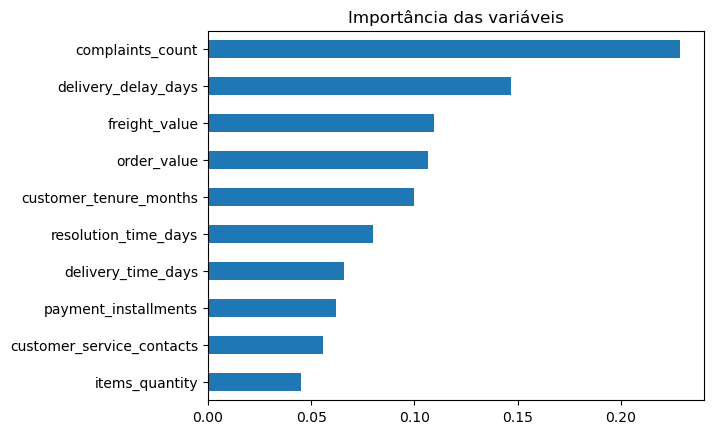

In [9]:
import matplotlib.pyplot as plt

importances = pd.Series(model.feature_importances_, index=features)
importances = importances.sort_values()

plt.figure()
importances.plot(kind='barh')
plt.title("Importância das variáveis")
plt.show()

<h3 style="color:#2E86C1;">
Principais variáveis
</h3>

As variáveis com maior importância no modelo são:

1. `complaints_count`  
2. `delivery_delay_days`  
3. `freight_value`  

<h3 style="color:#2E86C1;">
Insight principal
</h3>

A insatisfação do cliente é fortemente explicada por problemas ao longo da jornada.

<h3 style="color:#2E86C1;">
Interpretação dos resultados
</h3>

As variáveis mais relevantes estão diretamente alinhadas aos fatores identificados no EDA, reforçando a consistência da análise.

O número de reclamações (`complaints_count`) se destaca como o principal preditor de insatisfação, indicando que o acúmulo de problemas ao longo da jornada tem forte impacto na percepção do cliente.

O atraso na entrega (`delivery_delay_days`) também aparece como um fator crítico, reforçando o papel da logística na experiência.

Outras variáveis, como o valor do frete, apresentam impacto moderado, enquanto variáveis como número de contatos e tempo de resolução têm menor influência direta no modelo, possivelmente por estarem correlacionadas com o número de reclamações.

<h3 style="color:#2E86C1;">
Conclusão
</h3>

Os resultados indicam que a insatisfação do cliente é explicada principalmente por falhas operacionais acumuladas ao longo da jornada, com destaque para reclamações e atrasos na entrega.

<h2 style="color:#2E86C1; border-bottom: 2px solid #2E86C1; padding-bottom: 5px;">
8. Score de risco
</h2>

Além da classificação binária, o modelo gera uma probabilidade de insatisfação (`y_prob`), que pode ser interpretada como um score de risco.

Essa probabilidade permite priorizar clientes de forma mais granular, em vez de apenas classificá-los como detratores ou não.

Na prática, o score pode ser utilizado para:

- identificar clientes com maior probabilidade de insatisfação  
- priorizar atendimentos ou ações preventivas  
- definir diferentes níveis de intervenção ao longo da jornada  

Dessa forma, o modelo deixa de ser apenas uma ferramenta de classificação e passa a atuar como um mecanismo de priorização operacional.

In [10]:
y_prob = model.predict_proba(X_test)[:,1]

df_test = X_test.copy()
df_test['risk_score'] = y_prob
df_test['target_detractor'] = y_test.values
df_test['nps_score'] = df.loc[X_test.index, 'nps_score']
pd.Series(y_prob).describe()

count    500.000000
mean       0.733870
std        0.256617
min        0.050000
25%        0.558750
50%        0.840000
75%        0.945000
max        1.000000
dtype: float64

<h3 style="color:#2E86C1;">
Estatísticas do score
</h3>

- média: ~0.73  
- mediana: ~0.83  
- 75% dos clientes possuem probabilidade acima de 0.95  
- mínimo: ~0.06  

<h3 style="color:#2E86C1;">
Interpretação
</h3>

Observa-se que a maioria dos clientes no conjunto de teste apresenta alta probabilidade de ser classificada como detrator.

Esse comportamento pode indicar:

- presença relevante de clientes insatisfeitos na base  
- possível tendência do modelo a atribuir probabilidades elevadas  
- necessidade de avaliar a calibração e a distribuição das probabilidades  

<h3 style="color:#2E86C1;">
Insight principal
</h3>

O score permite ordenar os clientes por risco de insatisfação, facilitando a priorização de ações.

Na prática, o score pode ser usado para segmentar clientes em diferentes níveis de prioridade:

- **alto risco** → intervenção imediata  
- **médio risco** → monitoramento  
- **baixo risco** → acompanhamento padrão  

Isso permite alocar recursos de forma mais eficiente, direcionando esforços para os clientes com maior probabilidade de insatisfação.

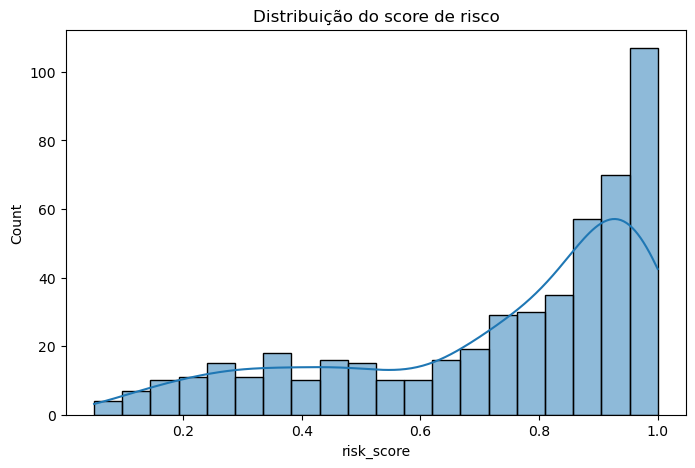

In [11]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df_test['risk_score'], bins=20, kde=True)
plt.title("Distribuição do score de risco")
plt.show()

<h3 style="color:#2E86C1;">
Distribuição do score
</h3>

A distribuição do score apresenta concentração em valores elevados, indicando que o modelo tende a atribuir alta probabilidade de insatisfação para uma parcela significativa dos clientes.

Esse comportamento pode estar relacionado a:

- desbalanceamento da base  
- forte relação entre variáveis operacionais e o NPS  
- possível tendência do modelo a superestimar probabilidades (overconfidence)  

Esse padrão reforça a importância de avaliar a calibração do modelo, especialmente se o score for utilizado diretamente na tomada de decisão.

In [12]:
df_test['risk_bucket'] = pd.qcut(
    df_test['risk_score'],
    q=3,
    labels=['Baixo', 'Médio', 'Alto']
)

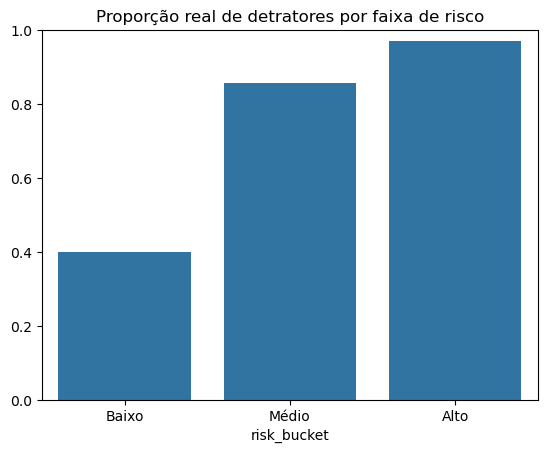

In [13]:
risk_rate = df_test.groupby('risk_bucket', observed=True)['target_detractor'].mean()

sns.barplot(x=risk_rate.index, y=risk_rate.values)
plt.title("Proporção real de detratores por faixa de risco")
plt.ylim(0,1)
plt.show()

<h3 style="color:#2E86C1;">
Validação do score
</h3>

A proporção de detratores aumenta de forma consistente entre as faixas de risco, indicando que o modelo consegue ordenar corretamente os clientes.

Embora a separação não seja perfeita, o comportamento monotônico mostra que o modelo tem valor prático para priorização.

Isso reforça que o score pode ser utilizado como um ranking de risco, permitindo direcionar ações de forma mais eficiente para os clientes com maior probabilidade de insatisfação.

In [14]:
df_test['risk_bucket'].value_counts(normalize=True)

risk_bucket
Baixo    0.336
Médio    0.334
Alto     0.330
Name: proportion, dtype: float64

In [15]:
df_test['nps_score'] = df.loc[X_test.index, 'nps_score']

df_test.groupby('risk_bucket')['nps_score'].mean()

risk_bucket
Baixo    6.404762
Médio    4.046108
Alto     2.317576
Name: nps_score, dtype: float64

<h2 style="color:#2E86C1; border-bottom: 2px solid #2E86C1; padding-bottom: 5px;">
9. Conclusão
</h2>

O modelo foi capaz de capturar padrões relevantes na base de dados, confirmando que variáveis operacionais são fortes preditores de insatisfação.

Apesar da concentração de probabilidades em valores elevados, o modelo demonstra boa capacidade de ordenação de risco, sendo útil para identificar clientes com maior probabilidade de se tornarem detratores.

Do ponto de vista de negócio, o modelo permite:

- priorizar clientes com maior risco de insatisfação  
- atuar de forma preventiva ao longo da jornada  
- melhorar a experiência do cliente de forma direcionada  

Dessa forma, a modelagem complementa o EDA ao transformar a análise em capacidade preditiva, viabilizando a aplicação prática dos insights no contexto operacional.